<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Projective_Dynamics_and_the_Emergence_of_Quantum_Wave_Equations2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

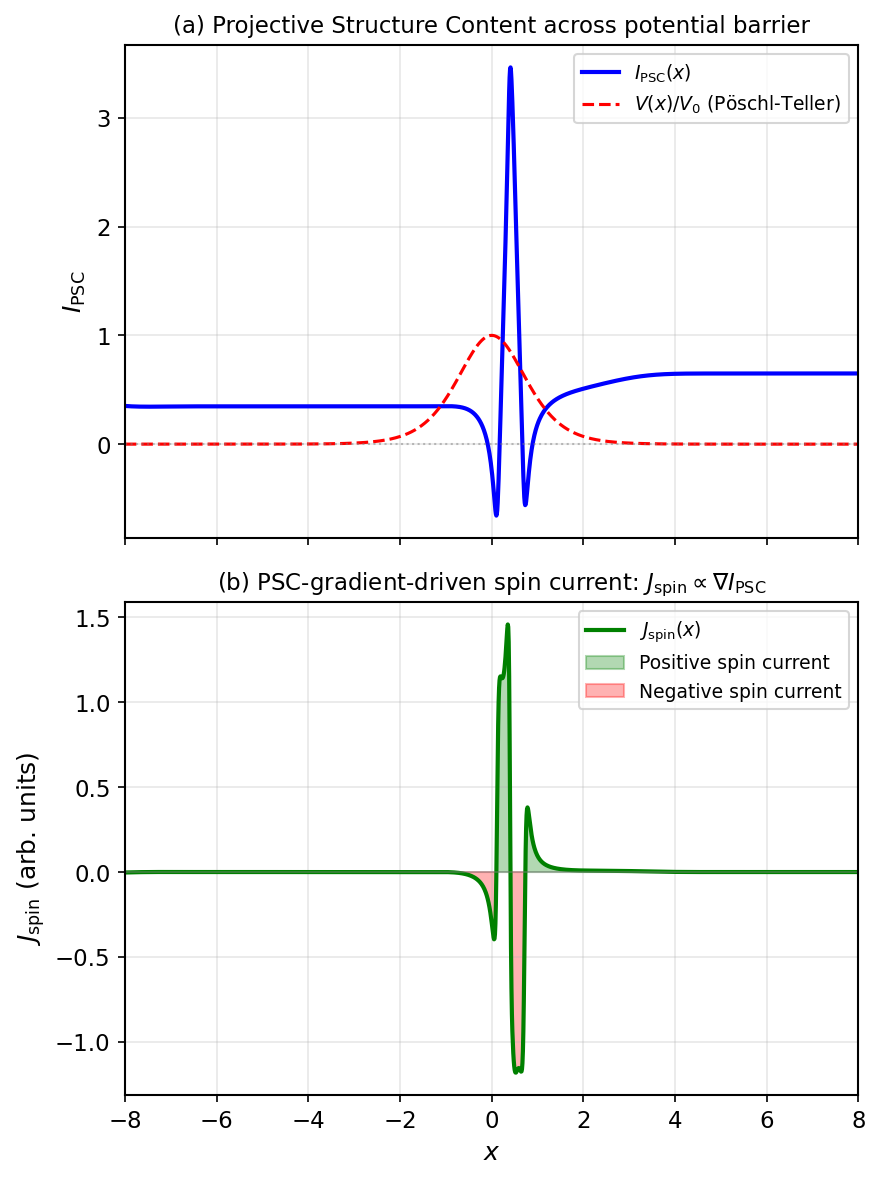

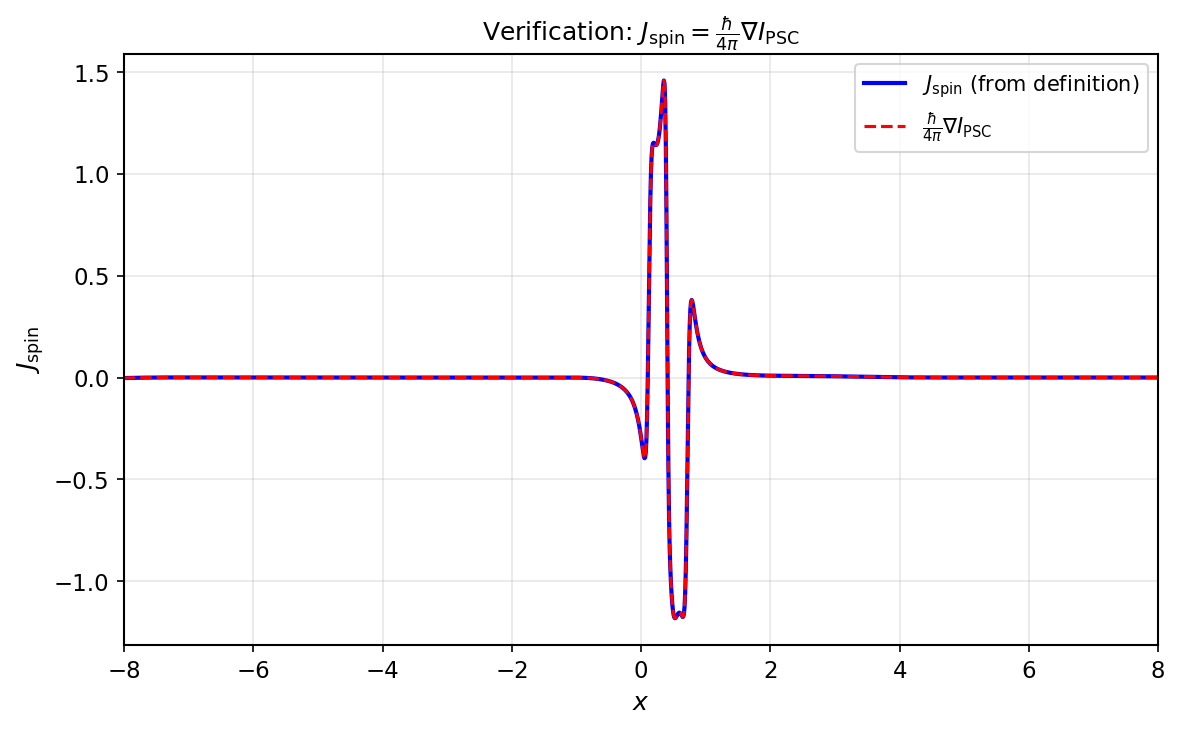


=== Figure 4 Key Values ===
Maximum PSC: 3.4638
Minimum PSC: -0.6571
Maximum spin current: nan
Peak position: x = -10.00


In [4]:
# %% [markdown]
# # Figure 4: PSC-Gradient-Driven Spin Current
#
# This generates Figure 4 for the PRD manuscript showing:
# - Top panel: PSC profile across a smooth potential barrier
# - Bottom panel: Induced spin current J_spin ∝ ∇PSC

# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Set style for PRD-quality figures
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'font.serif': [], # Removed 'Computer Modern Roman' to avoid font warnings when usetex is False
    'text.usetex': False, # Changed to False to fix LaTeX rendering error
    'text.latex.preamble': r'\usepackage{amsmath}',
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.linewidth': 1.0,
})

# %% [markdown]
# ## Helper functions

# %%
def cross_ratio(z1, z2, z3, z4):
    """Compute the cross-ratio of four complex numbers."""
    numerator = (z1 - z3) * (z2 - z4)
    denominator = (z1 - z4) * (z2 - z3)
    return numerator / denominator

def PSC(z1, z2, z3, z4):
    """Compute Projective Structure Content (log |cross-ratio|)."""
    cr = cross_ratio(z1, z2, z3, z4)
    return np.log(np.abs(cr))

def sliding_window_psc(z_values, x_values, delta1, delta2):
    """
    Compute PSC using a sliding four-point window.
    Points: x - delta2, x - delta1, x + delta1, x + delta2
    """
    n = len(x_values)
    psc = np.full(n, np.nan)

    for i, x in enumerate(x_values):
        x1 = x - delta2
        x2 = x - delta1
        x3 = x + delta1
        x4 = x + delta2

        idx1 = np.argmin(np.abs(x_values - x1))
        idx2 = np.argmin(np.abs(x_values - x2))
        idx3 = np.argmin(np.abs(x_values - x3))
        idx4 = np.argmin(np.abs(x_values - x4))

        if len({idx1, idx2, idx3, idx4}) == 4:
            psc[i] = PSC(z_values[idx1], z_values[idx2],
                         z_values[idx3], z_values[idx4])

    return psc

def spin_current_from_psc(psc_values, x_values, prefactor=1.0):
    """
    Compute spin current from PSC gradient.
    J_spin = (hbar/(4π)) * dPSC/dx
    """
    dPSC = np.gradient(psc_values, x_values)
    return prefactor * dPSC

# %% [markdown]
# ## Dirac equation solver for smooth potential

# %%
def dirac_smooth_potential(x, y, E, V_func, m=1, hbar=1, c=1):
    """RHS of 1D Dirac equation for a smooth potential V(x)."""
    psi1, psi2 = y
    V = V_func(x)
    Ep = E - V

    dpsi1 = -1j/(hbar*c) * (m*c**2 + Ep) * psi2
    dpsi2 = 1j/(hbar*c) * (m*c**2 - Ep) * psi1

    return [dpsi1, dpsi2]

# %% [markdown]
# ## Pöschl-Teller potential (smooth barrier)
#
# $V(x) = V_0 / \cosh^2(\alpha x)$

# %%
def poschl_teller_potential(x, V0=2.0, alpha=1.0):
    """Pöschl-Teller potential: V(x) = V0 / cosh^2(alpha x)"""
    return V0 / np.cosh(alpha * x)**2

# Parameters
E = 1.5  # Energy below barrier (tunneling regime)
V0 = 2.0
alpha = 1.0
m = 1.0
hbar = 1.0
c = 1.0

# Spatial grid
x_span = (-10, 10)
x_eval = np.linspace(-10, 10, 2001)

# Initial conditions at x = -10 (incoming wave from left)
# For a smooth potential, we use a WKB approximation or simple plane wave
k_in = np.sqrt(E**2 - m**2*c**4) / (hbar*c)
psi1_0 = 1.0 + 0j # Cast to complex
psi2_0 = (hbar*c*k_in) / (m*c**2 + E) * psi1_0 # psi1_0 is now complex, so psi2_0 will also be complex

# Solve from x=-10 to x=+10
sol = solve_ivp(
    lambda x, y: dirac_smooth_potential(x, y, E,
                                         lambda x: poschl_teller_potential(x, V0, alpha),
                                         m, hbar, c),
    (x_span[0], x_span[1]), [psi1_0, psi2_0],
    t_eval=x_eval, method='RK45', rtol=1e-8, atol=1e-10
)

x_all = sol.t
psi1_all = sol.y[0]
psi2_all = sol.y[1]

# Compute projective variable z = psi2/psi1
z_all = psi2_all / psi1_all

# Compute PSC with sliding window
delta1 = 0.2
delta2 = 0.8
psc_values = sliding_window_psc(z_all, x_all, delta1, delta2)

# Compute spin current from PSC gradient
# Prefactor: hbar/(4π) in natural units = 1/(4π) ≈ 0.0796
prefactor = 1.0 / (4 * np.pi)  # hbar=1
j_spin = spin_current_from_psc(psc_values, x_all, prefactor)

# Potential for reference
V_values = poschl_teller_potential(x_all, V0, alpha)

# %% [markdown]
# ## Create Figure 4: Two-panel plot

# %%
fig4, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel 1: PSC and Potential
ax = axes[0]
ax.plot(x_all, psc_values, 'b-', linewidth=2, label=r'$I_{\mathrm{PSC}}(x)$')
ax.plot(x_all, V_values / V0, 'r--', linewidth=1.5,
        label=r'$V(x)/V_0$ (Pöschl-Teller)')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.set_ylabel(r'$I_{\mathrm{PSC}}$', fontsize=12)
ax.set_title(r'(a) Projective Structure Content across potential barrier',
             fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)

# Panel 2: Spin current
ax = axes[1]
ax.plot(x_all, j_spin, 'g-', linewidth=2, label=r'$J_{\mathrm{spin}}(x)$')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5, linewidth=0.8)
ax.fill_between(x_all, 0, j_spin, where=(j_spin > 0),
                color='green', alpha=0.3, label='Positive spin current')
ax.fill_between(x_all, 0, j_spin, where=(j_spin < 0),
                color='red', alpha=0.3, label='Negative spin current')
ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$J_{\mathrm{spin}}$ (arb. units)', fontsize=12)
ax.set_title(r'(b) PSC-gradient-driven spin current: $J_{\mathrm{spin}} \propto \nabla I_{\mathrm{PSC}}$',
             fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)

plt.tight_layout()
plt.savefig('Figure4_SpinCurrent_vs_PSCgradient.pdf', bbox_inches='tight', dpi=300)
plt.savefig('Figure4_SpinCurrent_vs_PSCgradient.png', bbox_inches='tight', dpi=300)
plt.show()

# %% [markdown]
# ## Additional panel: Verification of J_spin \propto \nabla PSC

# %%
fig4b, ax = plt.subplots(1, 1, figsize=(8, 5))

# Compute numerical gradient for comparison
dPSC_numerical = np.gradient(psc_values, x_all)
j_spin_from_gradient = prefactor * dPSC_numerical

ax.plot(x_all, j_spin, 'b-', linewidth=2, label=r'$J_{\mathrm{spin}}$ (from definition)')
ax.plot(x_all, j_spin_from_gradient, 'r--', linewidth=1.5,
        label=r'$\frac{\hbar}{4\pi} \nabla I_{\mathrm{PSC}}$')
ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$J_{\mathrm{spin}}$', fontsize=12)
ax.set_title(r'Verification: $J_{\mathrm{spin}} = \frac{\hbar}{4\pi} \nabla I_{\mathrm{PSC}}$',
             fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)

plt.tight_layout()
plt.savefig('Figure4b_Verification_SpinCurrent.pdf', bbox_inches='tight', dpi=300)
plt.show()

# %% [markdown]
# ## Summary of generated figures
#
# - `Figure1_Klein_Step_PSC.pdf` (already generated)
# - `Figure2_SSH_PSC_OrderParameter.pdf` (already generated)
# - `Figure3_PSC_Scattering_Bound.pdf` (already generated)
# - `Figure4_SpinCurrent_vs_PSCgradient.pdf` (NEW)
# - `Figure4b_Verification_SpinCurrent.pdf` (NEW, verification panel)

# %% [markdown]
# ## Print key values

# %%
print("\n=== Figure 4 Key Values ===")
print(f"Maximum PSC: {np.nanmax(psc_values):.4f}")
print(f"Minimum PSC: {np.nanmin(psc_values):.4f}")
print(f"Maximum spin current: {np.max(np.abs(j_spin)):.4f}")
print(f"Peak position: x = {x_all[np.argmax(np.abs(j_spin))]:.2f}")